In [28]:
# 加载数据
import torch
from joblib import dump, load
import torch.utils.data as Data
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_set = load('../dataresult/train_set.pkl')


def dataloader(batch_size, workers=2):
    # 训练集
    train_set = load('../dataresult/train_set.pkl')
    train_label = load('../dataresult/train_label.pkl')
    # 测试集
    test_set = load('../dataresult/test_set.pkl')
    test_label = load('../dataresult/test_label.pkl')

    # 加载数据
    train_loader = Data.DataLoader(dataset=Data.TensorDataset(train_set, train_label),
                                   batch_size=batch_size, num_workers=workers, drop_last=True)
    test_loader = Data.DataLoader(dataset=Data.TensorDataset(test_set, test_label),
                                  batch_size=batch_size, num_workers=workers, drop_last=True)
    return train_loader, test_loader

batch_size = 32
# 加载数据
train_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(test_loader))

24
9


In [29]:
from torch.nn import Transformer, TransformerEncoder, TransformerEncoderLayer
# 定义 CNNTransformer 模型
class CNNTransformer(nn.Module):
    def __init__(self, input_dim, conv_archs, hidden_dim, num_layers, num_heads, output_dim, dropout_rate=0.5):
        """
        params:
        input_dim          : 输入数据的维度
        conv_archs         : cnn 网络结构
        hidden_dim         : 注意力维度
        num_layers         : Transformer编码器层数
        num_heads          : 多头注意力头数
        output_dim         : 输出维度
        dropout_rate        : 随机丢弃神经元的概率
        """
        super().__init__()
        # 参数
        self.output_dim = output_dim

        # CNN参数
        self.conv_arch = conv_archs # cnn网络结构
        self.input_channels = input_dim # 输入通道数
        self.cnn_features = self.make_layers()

          # Transformer编码器
        self.hidden_dim = hidden_dim
        # Time Transformer layers
        self.transformer = TransformerEncoder(
            TransformerEncoderLayer(conv_archs[-1][-1], num_heads, hidden_dim, dropout=dropout_rate, batch_first=True),
            num_layers
        )

        # 序列平局池化
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # 定义线性层
        self.linear  = nn.Linear(conv_archs[-1][-1], output_dim)

      # CNN卷积池化结构
    def make_layers(self):
        layers = []
        for (num_convs, out_channels) in self.conv_arch:
            for _ in range(num_convs):
                layers.append(nn.Conv1d(self.input_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.ReLU(inplace=True))
                self.input_channels = out_channels
            # layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)

    def forward(self, input_seq):
        batch_size = input_seq.size(0)
        # CNN 卷积池化
        # CNN 网络输入[batch,H_in, seq_length]
        # 调换维度[B, L, D] --> [B, D, L]
        input_seq = input_seq.permute(0,2,1)
        cnn_features = self.cnn_features(input_seq) # torch.Size([32, 32, 1])
        # print(cnn_features.size())
        
        # 调换维度[B, D, L] --> [B, L, D]
        cnn_features = cnn_features.permute(0,2,1)

        # Time-Transformer 处理
        # 在PyTorch中，transformer模型的性能与batch_first参数的设置相关。
        # 当batch_first为True时，输入的形状应为(batch, sequence, feature)，这种设置在某些情况下可以提高推理性能。
        transformer_output = self.transformer(cnn_features)  #  torch.Size([32, 1, 32])
        # 序列平均池化操作
        output_avgpool = self.avgpool(transformer_output.transpose(1, 2))  #  torch.Size([32, 32, 1])
        output_avgpool = output_avgpool.reshape(batch_size, -1)  #  torch.Size([32, 32])
        predict = self.linear(output_avgpool) 
        return predict

In [30]:
# 定义模型参数
input_dim = 9    # 输入维度为 14 个维度
conv_archs = ((1, 32),)   # CNN 层卷积池化结构  类似VGG
output_dim = 1   # 输出维度 为1
# Transformer参数
hidden_dim = 64  # 注意力维度
num_layers = 2   # 编码器层数
num_heads = 4   # 多头注意力头数

model = CNNTransformer(input_dim, conv_archs, hidden_dim, num_layers, num_heads, output_dim)  

# 定义损失函数和优化函数 
loss_function = nn.MSELoss()  # loss
learn_rate = 0.0003
optimizer = torch.optim.Adam(model.parameters(), learn_rate)  # 优化器

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

   864
    32
  3072
    96
  1024
    32
  2048
    64
  2048
    32
    32
    32
    32
    32
  3072
    96
  1024
    32
  2048
    64
  2048
    32
    32
    32
    32
    32
    32
     1
______
 18017


In [31]:
print(model)

CNNTransformer(
  (cnn_features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.5, inplace=False)
        (dropout2): Dropout(p=0.5, inplace=False)
      )
    )
  )
  (avgpool): AdaptiveAvgPool1d(output_size=1)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)


In [32]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

# 在训练前运行
print("训练集样本数:", len(train_set))
print("batch_size:", batch_size)
print("理论批次数:", len(train_set) // batch_size)
print("实际批次数:", len(train_loader))

# 检查第一个批次
for data, _ in train_loader:
    print("第一个批次大小:", len(data))
    break

# def model_train(epochs, model, optimizer, loss_function, train_loader, device):
#     model = model.to(device)
#
#     # 最低MSE
#     minimum_mse = 1000.
#     # 最佳模型
#     best_model = model
#
#     train_mse = []     # 记录在训练集上每个epoch的 MSE 指标的变化情况   平均值
#
#     # 计算模型运行时间
#     start_time = time.time()
#     for epoch in range(epochs):
#          # 训练
#         model.train()
#         train_mse_loss = []    #保存当前epoch的MSE loss和
#         for seq, labels in train_loader:
#             seq, labels = seq.to(device), labels.to(device)
#             # 每次更新参数前都梯度归零和初始化
#             optimizer.zero_grad()
#             # 前向传播
#             y_pred = model(seq)  #   torch.Size([16, 10])
#             # 损失计算
#             loss = loss_function(y_pred, labels)
#             train_mse_loss.append(loss.item()) # 计算 MSE 损失
#             # 反向传播和参数更新
#             loss.backward()
#             optimizer.step()
#         #     break
#         # break
#         # 计算总损失
#         train_av_mseloss = np.average(train_mse_loss) # 平均
#         train_mse.append(train_av_mseloss)
#         print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')
#
#         # 如果当前模型的 MSE 低于于之前的最佳准确率，则更新最佳模型
#         #保存当前最优模型参数
#         if train_av_mseloss < minimum_mse:
#             minimum_mse = train_av_mseloss
#             best_model = model# 更新最佳模型的参数
#
#     # 保存最后的参数
#     # torch.save(model, 'final_model_cnn_transformer.pt')
#     # 保存最好的参数
#     torch.save(best_model, 'best_model_cnn_transformer.pt')
#     print(f'\nDuration: {time.time() - start_time:.0f} seconds')
#
#     # 可视化
#     # plt.plot(range(epochs), train_mse, color = 'b',label = 'train_MSE-loss')
#     # plt.legend()
#     # plt.show()   #显示 lable
#     # print(f'min_MSE: {minimum_mse}')
#
# #  模型训练
# epochs = 50
# model_train(epochs, model, optimizer, loss_function, train_loader, device)

训练集样本数: 796
batch_size: 32
理论批次数: 24
实际批次数: 24
第一个批次大小: 32


In [33]:
def model_train(epochs, model, optimizer, loss_function, train_loader, device):
    model = model.to(device)

    minimum_mse = 1000.
    best_model = model
    train_mse = []

    accumulation_steps = 4
    batch_size = 32  # 明确指定

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        train_mse_loss = []
        optimizer.zero_grad()

        total_batches = len(train_loader)

        for batch_idx, (seq, labels) in enumerate(train_loader):
            seq, labels = seq.to(device), labels.to(device)
            actual_batch_size = len(seq)

            # ============ 正确识别最后批次 ============
            is_last_batch = (batch_idx == total_batches - 1)
            is_small_batch = is_last_batch and (actual_batch_size < batch_size)
            # =========================================

            y_pred = model(seq)
            loss = loss_function(y_pred, labels)

            if is_small_batch:
                # 最后小批次：大幅降低影响
                weight = actual_batch_size / batch_size * 0.1  # 再打1折
                loss = loss * weight
                print(f"  最后批次({actual_batch_size}样本)，权重{weight:.2f}")
            else:
                # 正常批次
                loss = loss * (actual_batch_size / batch_size)

            # 反向传播
            loss.backward()

            # ============ 小批次不触发更新 ============
            if not is_small_batch:
                if (batch_idx + 1) % accumulation_steps == 0:
                    optimizer.step()
                    optimizer.zero_grad()
            # ========================================

            # 记录损失
            if is_small_batch:
                recorded_loss = loss.item() / 0.1  # 还原
            else:
                recorded_loss = loss.item() * (batch_size / actual_batch_size)
            train_mse_loss.append(recorded_loss)

        # 最后批次处理：如果是小批次则不更新
        last_seq, _ = next(iter(train_loader)) if train_loader else (None, None)
        last_batch_size = len(last_seq) if last_seq is not None else 0
        is_last_small = (last_batch_size < batch_size)

        if not is_last_small:
            if total_batches % accumulation_steps != 0:
                optimizer.step()
                optimizer.zero_grad()

        train_av_mseloss = np.average(train_mse_loss)
        train_mse.append(train_av_mseloss)
        print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')

        if train_av_mseloss < minimum_mse:
            minimum_mse = train_av_mseloss
            best_model = model

    torch.save(best_model, 'best_model_cnn_transformer.pt')
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')

    return best_model, train_mse
#  模型训练
epochs = 50
model_train(epochs, model, optimizer, loss_function, train_loader, device)

Epoch:  1 train_MSE-Loss: 0.98449068
Epoch:  2 train_MSE-Loss: 0.81688422
Epoch:  3 train_MSE-Loss: 0.69849621
Epoch:  4 train_MSE-Loss: 0.65795279
Epoch:  5 train_MSE-Loss: 0.62091926
Epoch:  6 train_MSE-Loss: 0.60373658
Epoch:  7 train_MSE-Loss: 0.57663801
Epoch:  8 train_MSE-Loss: 0.54945598
Epoch:  9 train_MSE-Loss: 0.52999943
Epoch: 10 train_MSE-Loss: 0.50901407
Epoch: 11 train_MSE-Loss: 0.48492803
Epoch: 12 train_MSE-Loss: 0.45839746
Epoch: 13 train_MSE-Loss: 0.44903195
Epoch: 14 train_MSE-Loss: 0.41313101
Epoch: 15 train_MSE-Loss: 0.39537755
Epoch: 16 train_MSE-Loss: 0.38166713
Epoch: 17 train_MSE-Loss: 0.36374148
Epoch: 18 train_MSE-Loss: 0.35359193
Epoch: 19 train_MSE-Loss: 0.33129214
Epoch: 20 train_MSE-Loss: 0.30926601
Epoch: 21 train_MSE-Loss: 0.30067765
Epoch: 22 train_MSE-Loss: 0.28364195
Epoch: 23 train_MSE-Loss: 0.28032372
Epoch: 24 train_MSE-Loss: 0.25902744
Epoch: 25 train_MSE-Loss: 0.24829121
Epoch: 26 train_MSE-Loss: 0.24101381
Epoch: 27 train_MSE-Loss: 0.22830904
E

(CNNTransformer(
   (cnn_features): Sequential(
     (0): Conv1d(9, 32, kernel_size=(3,), stride=(1,), padding=(1,))
     (1): ReLU(inplace=True)
   )
   (transformer): TransformerEncoder(
     (layers): ModuleList(
       (0-1): 2 x TransformerEncoderLayer(
         (self_attn): MultiheadAttention(
           (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
         )
         (linear1): Linear(in_features=32, out_features=64, bias=True)
         (dropout): Dropout(p=0.5, inplace=False)
         (linear2): Linear(in_features=64, out_features=32, bias=True)
         (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
         (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
         (dropout1): Dropout(p=0.5, inplace=False)
         (dropout2): Dropout(p=0.5, inplace=False)
       )
     )
   )
   (avgpool): AdaptiveAvgPool1d(output_size=1)
   (linear): Linear(in_features=32, out_features=1, bias=True)
 ),
 [0.98449067538604

### 第一部分，训练集评估

In [34]:
# 模型预测
# 模型 测试集 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn_transformer.pt')
model = model.to(device)

# 预测数据
origin_data = []
pre_data = []
with torch.no_grad():
        for data, label in train_loader:
            # 原始标签
            origin_lable = label.tolist()
            origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            train_pred = model(data)  # 对测试集进行预测
            train_pred = train_pred.tolist()
            pre_data += train_pred      

In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
origin_data = scaler.inverse_transform(origin_data)
pre_data = scaler.inverse_transform(pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(origin_data, pre_data)
print('训练集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
train_mse = mean_squared_error(origin_data, pre_data)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(origin_data, pre_data)
print('训练数据集上的均方误差-MSE: ',train_mse)
print('训练数据集上的均方根误差-RMSE: ',train_rmse)
print('训练数据集上的平均绝对误差-MAE: ',train_mae)

训练集上 模型分数-R^2: 0.8073231416854537
**************************************************
训练数据集上的均方误差-MSE:  0.01490878208067573
训练数据集上的均方根误差-RMSE:  0.12210152366238404
训练数据集上的平均绝对误差-MAE:  0.09287095849123832


# 测试集评估

In [36]:
# 模型 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_cnn_transformer.pt')
model = model.to(device)

# 预测数据
test_origin_data = []
test__pre_data = []
with torch.no_grad():
        for data, label in test_loader:
            # 原始标签
            origin_lable = label.tolist()
            test_origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            pred = model(data)  # 对测试集进行预测
            pred = pred.tolist()
            test__pre_data += pred        

In [37]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
test_origin_data = scaler.inverse_transform(test_origin_data)
test__pre_data = scaler.inverse_transform(test__pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(test_origin_data, test__pre_data)
print('测试集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
test_mse = mean_squared_error(test_origin_data, test__pre_data)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_origin_data, test__pre_data)
print('测试数据集上的均方误差-MSE: ',test_mse)
print('测试数据集上的均方根误差-RMSE: ',test_rmse)
print('测试数据集上的平均绝对误差-MAE: ',test_mae)

测试集上 模型分数-R^2: 0.1505441776109092
**************************************************
测试数据集上的均方误差-MSE:  0.05691222165678226
测试数据集上的均方根误差-RMSE:  0.2385628253873228
测试数据集上的平均绝对误差-MAE:  0.17687227347905818


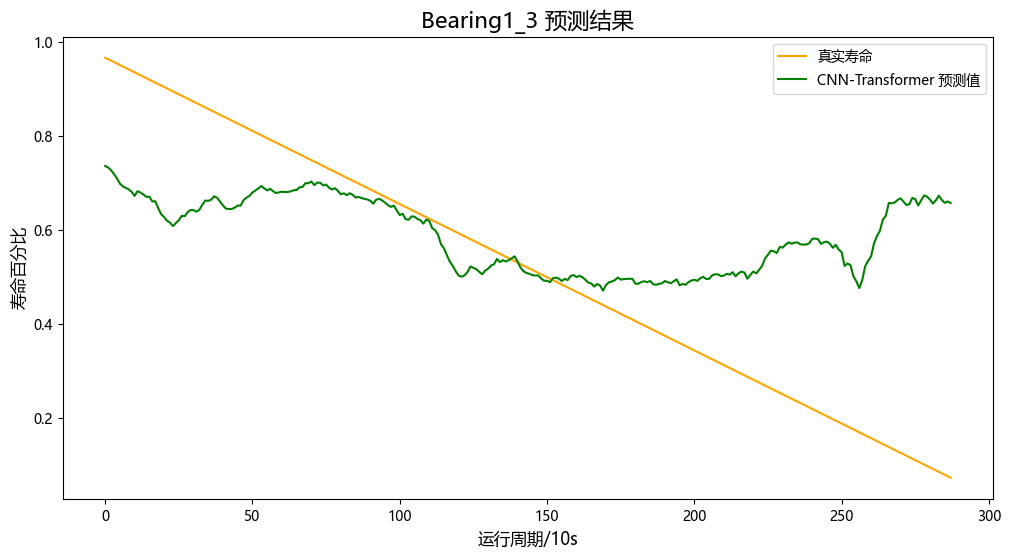

['../画图对比/cnn_transformer_pre']

In [38]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

# 可视化结果
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test_origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(test__pre_data, label='CNN-Transformer 预测值',color='green')  # 预测值

# plt.plot([-1,170],[2.0*0.7,2.0*0.7],c='black',lw=1,ls='--')  # 临界点直线  可自己调整位置

plt.xlabel('运行周期/10s', fontsize=12)
plt.ylabel('寿命百分比', fontsize=12)
plt.title('Bearing1_3 预测结果', fontsize=16)
plt.legend()
plt.show()

# 保存数据
# 保存数据
dump(test_origin_data, '../画图对比/cnn_transformer_origin') 
dump(test__pre_data, '../画图对比/cnn_transformer_pre')

In [39]:
# 前2304个MAE
mae_false_first_2304 = mean_absolute_error(
    test_origin_data[:288],
    test__pre_data[:288]
)

# 最后61个MAE
mae_last_23 = mean_absolute_error(
    test_origin_data[288:],
    test__pre_data[288:]
)

print(f"实验2 - 总MAE: {test_mae:.6f}")
print(f"实验2 - 前288个MAE: {mae_false_first_2304:.6f}")
print(f"实验2 - 最后{len(test_origin_data)-288}个MAE: {mae_last_23:.6f}")

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required.